Risk score - target variable


In [18]:
# train_models_final_hgb.py
import os
import joblib
import numpy as np
import pandas as pd
from time import time
from scipy import sparse
import re

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
DATA_PATH = "../data/ml_dataset_cleaned_fast.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# -----------------------------
# Text preprocessing utilities
# -----------------------------
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_TAG_RE = re.compile(r"<[^>]+>")
NON_ALNUM_RE = re.compile(r"[^a-z0-9\s]")
MULTI_WS_RE = re.compile(r"\s+")


def clean_text(s: str) -> str:
    """
    Lightweight deterministic text cleaner for CVE descriptions:
      - ensure string, lower-case
      - strip URLs
      - remove HTML tags
      - remove non-alphanumeric characters (keeps spaces)
      - collapse multiple whitespace to single space
      - trim
    This function is intentionally simple (no heavy external deps).
    """
    if s is None:
        return ""
    if not isinstance(s, str):
        s = str(s)
    s = s.lower()
    s = URL_RE.sub(" ", s)
    s = HTML_TAG_RE.sub(" ", s)
    s = NON_ALNUM_RE.sub(" ", s)
    s = MULTI_WS_RE.sub(" ", s)
    s = s.strip()
    return s


def fit_tfidf(X_train_text, max_features=5000, ngram_range=(1, 2), min_df=2):
    """
    Fit a TF-IDF vectorizer with the cleaning preprocessor and english stopwords.
    """
    tfidf = TfidfVectorizer(
    preprocessor=clean_text,
    stop_words=list(ENGLISH_STOP_WORDS),
    max_features=max_features,
    ngram_range=ngram_range,
    min_df=min_df,
    norm="l2",
    dtype=np.float32
)
    tfidf.fit(X_train_text)
    return tfidf


def prepare_preprocessor(numeric_cols, cat_cols):
    numeric_transformer = Pipeline([("scaler", StandardScaler())])
    # keep sparse_output=False for dense one-hot for easy hstack with dense numeric
    categorical_transformer = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, cat_cols)
        ],
        remainder="drop",
        sparse_threshold=0
    )
    return preprocessor


def combine_numcat_tfidf(preprocessor, tfidf, X_df, text_col):
    """
    Combine numeric+categorical (preprocessor -> dense ndarray) with TF-IDF (sparse).
    Returns a csr_matrix (sparse) ready for models that accept sparse input.
    """
    X_numcat = preprocessor.transform(X_df)  # dense ndarray (because sparse_threshold=0)
    X_text = tfidf.transform(X_df[text_col].fillna(""))  # sparse
    left = sparse.csr_matrix(X_numcat)
    right = X_text if sparse.issparse(X_text) else sparse.csr_matrix(X_text)
    return sparse.hstack([left, right], format="csr")


def cv_rmse(model, X, y, cv=5):
    # If model requires dense input (HistGradientBoostingRegressor), convert
    X_for_cv = X
    if sparse.issparse(X) and isinstance(model, HistGradientBoostingRegressor):
        X_for_cv = X.toarray()
    scores = cross_val_score(model, X_for_cv, y, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
    rmse_scores = np.sqrt(-scores)
    return float(rmse_scores.mean()), float(rmse_scores.std())


def main():
    print("Loading data:", DATA_PATH)
    df = pd.read_csv(DATA_PATH)
    print("Shape:", df.shape)

    text_col = "description_text"
    numeric_cols = ["years_since_published", "cvss_score", "references_count", "weaknesses_count", "os_count"]
    cat_cols = ["severity"]

    # ensure description_text exists
    if text_col not in df.columns:
        raise RuntimeError(f"Text column '{text_col}' not found in dataset.")

    X = df[numeric_cols + cat_cols + [text_col]].copy()
    y = df["risk_score"].astype(float).copy()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
    print("Train / Test shapes:", X_train.shape, X_test.shape)

    print("Preparing preprocessors...")
    preprocessor = prepare_preprocessor(numeric_cols, cat_cols)
    preprocessor.fit(X_train)

    # Fit TF-IDF using cleaned text (clean_text is applied internally in the vectorizer)
    print("Fitting TF-IDF vectorizer...")
    tfidf = fit_tfidf(X_train[text_col].fillna(""), max_features=5000, ngram_range=(1, 2), min_df=2)

    print("Transforming training data (sparse combine)...")
    X_train_comb = combine_numcat_tfidf(preprocessor, tfidf, X_train, text_col)
    X_test_comb = combine_numcat_tfidf(preprocessor, tfidf, X_test, text_col)

    print("Preparing Ridge training data (dense)...")
    X_train_num = preprocessor.transform(X_train)
    X_test_num = preprocessor.transform(X_test)
    # TF-IDF dense for ridge
    X_train_tfidf = tfidf.transform(X_train[text_col].fillna("")).toarray()
    X_test_tfidf = tfidf.transform(X_test[text_col].fillna("")).toarray()
    X_train_ridge = np.hstack([X_train_num, X_train_tfidf])
    X_test_ridge = np.hstack([X_test_num, X_test_tfidf])

    # ---------------- Model 1: RandomForest ----------------
    print("\nTraining RandomForestRegressor...")
    rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
    t0 = time()
    # RandomForest accepts sparse input (scikit-learn handles it)
    rf.fit(X_train_comb, y_train)
    t_rf = time() - t0
    preds_rf = rf.predict(X_test_comb)
    rf_rmse = rmse(y_test, preds_rf)
    rf_mae = mean_absolute_error(y_test, preds_rf)
    rf_r2 = r2_score(y_test, preds_rf)
    rf_cv_rmse, rf_cv_std = cv_rmse(rf, X_train_comb, y_train)
    print(f"RandomForest -> RMSE={rf_rmse:.4f}, MAE={rf_mae:.4f}, R2={rf_r2:.4f} (trained in {t_rf:.1f}s)")

    # ---------------- Model 2: HistGradientBoosting ----------------
    print("\nTraining HistGradientBoostingRegressor (requires dense input)...")
    hgb = HistGradientBoostingRegressor(
        max_iter=500, max_depth=8, learning_rate=0.05,
        random_state=RANDOM_STATE, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=25
    )
    # convert sparse -> dense for HGB
    X_train_comb_dense = X_train_comb.toarray()
    X_test_comb_dense = X_test_comb.toarray()
    t0 = time()
    hgb.fit(X_train_comb_dense, y_train)
    t_hgb = time() - t0
    preds_hgb = hgb.predict(X_test_comb_dense)
    hgb_rmse = rmse(y_test, preds_hgb)
    hgb_mae = mean_absolute_error(y_test, preds_hgb)
    hgb_r2 = r2_score(y_test, preds_hgb)
    hgb_cv_rmse, hgb_cv_std = cv_rmse(hgb, X_train_comb, y_train)
    print(f"HistGradientBoosting -> RMSE={hgb_rmse:.4f}, MAE={hgb_mae:.4f}, R2={hgb_r2:.4f} (trained in {t_hgb:.1f}s)")

    # ---------------- Model 3: Ridge ----------------
    print("\nTraining Ridge (linear) with TF-IDF features...")
    ridge = Ridge(alpha=1.0)
    t0 = time()
    ridge.fit(X_train_ridge, y_train)
    t_ridge = time() - t0
    preds_ridge = ridge.predict(X_test_ridge)
    ridge_rmse = rmse(y_test, preds_ridge)
    ridge_mae = mean_absolute_error(y_test, preds_ridge)
    ridge_r2 = r2_score(y_test, preds_ridge)
    ridge_cv_rmse, ridge_cv_std = cv_rmse(ridge, X_train_ridge, y_train)
    print(f"Ridge -> RMSE={ridge_rmse:.4f}, MAE={ridge_mae:.4f}, R2={ridge_r2:.4f} (trained in {t_ridge:.1f}s)")

    # ---------------- Compare and save best ----------------
    results = {
        "RandomForest": {"model": rf, "rmse": rf_rmse, "mae": rf_mae, "r2": rf_r2},
        "HistGradientBoosting": {"model": hgb, "rmse": hgb_rmse, "mae": hgb_mae, "r2": hgb_r2},
        "Ridge": {"model": ridge, "rmse": ridge_rmse, "mae": ridge_mae, "r2": ridge_r2}
    }

    best_name = min(results.keys(), key=lambda k: results[k]["rmse"])
    best_metrics = results[best_name]
    print("\n===== SUMMARY =====")
    for name, r in results.items():
        print(f"{name:25s} -> RMSE={r['rmse']:.4f}, MAE={r['mae']:.4f}, R2={r['r2']:.4f}")
    print(f"\nBest model by TEST RMSE: {best_name} (RMSE={best_metrics['rmse']:.4f})")

    model_package = {
        "model_name": best_name,
        "model": best_metrics["model"],
        "preprocessor": preprocessor,
        "tfidf": tfidf,
        "numeric_cols": numeric_cols,
        "cat_cols": cat_cols,
        "text_col": text_col,
    }

    save_path = os.path.join(MODEL_DIR, "best_model.joblib")
    joblib.dump(model_package, save_path)
    print("\nSaved best model package to:", save_path)


if __name__ == "__main__":
    main()

Loading data: ../data/ml_dataset_cleaned_fast.csv
Shape: (2428, 13)
Train / Test shapes: (1942, 7) (486, 7)
Preparing preprocessors...
Fitting TF-IDF vectorizer...
Transforming training data (sparse combine)...
Preparing Ridge training data (dense)...

Training RandomForestRegressor...
RandomForest -> RMSE=2.8816, MAE=0.3391, R2=0.9820 (trained in 1.2s)

Training HistGradientBoostingRegressor (requires dense input)...
HistGradientBoosting -> RMSE=2.4411, MAE=0.6862, R2=0.9871 (trained in 8.2s)

Training Ridge (linear) with TF-IDF features...
Ridge -> RMSE=3.6690, MAE=1.6655, R2=0.9709 (trained in 0.2s)

===== SUMMARY =====
RandomForest              -> RMSE=2.8816, MAE=0.3391, R2=0.9820
HistGradientBoosting      -> RMSE=2.4411, MAE=0.6862, R2=0.9871
Ridge                     -> RMSE=3.6690, MAE=1.6655, R2=0.9709

Best model by TEST RMSE: HistGradientBoosting (RMSE=2.4411)

Saved best model package to: ../models/best_model.joblib


In [24]:
# backend/test_model.py
import os
import joblib
import pandas as pd
from scipy import sparse

MODEL_PATH = os.path.join("..", "models", "best_model.joblib")  # adjust if you moved it

def combine_numcat_tfidf(preprocessor, tfidf, X_df, text_col):
    # preprocessor.transform -> dense ndarray (if you used sparse_output=False in OneHot)
    X_numcat = preprocessor.transform(X_df)  # numpy ndarray
    X_text = tfidf.transform(X_df[text_col].fillna(""))  # sparse matrix
    left = sparse.csr_matrix(X_numcat)
    right = X_text if sparse.issparse(X_text) else sparse.csr_matrix(X_text)
    return sparse.hstack([left, right], format="csr")

def main():
    pkg = joblib.load(MODEL_PATH)
    print("Loaded model package. Model:", pkg.get("model_name"))

    model = pkg["model"]
    preprocessor = pkg["preprocessor"]
    tfidf = pkg["tfidf"]
    numeric_cols = pkg["numeric_cols"]
    cat_cols = pkg["cat_cols"]
    text_col = pkg["text_col"]

    # --- SAMPLE inputs (3 examples) ---
    # Fields must match numeric_cols + cat_cols + text_col
    samples = [
        {
            # recent, high CVSS, many refs, CWE present, windows mention, RCE text
            "years_since_published": 0.05,
            "cvss_score": 97,
            "references_count": 5,
            "weaknesses_count": 2,
            "os_count": 1,            # if you use os_count in numeric_cols
            "severity": "CRITICAL",
            "description_text": "information disclosure."
        },
        {
            # older, medium CVSS, few refs, SQLi mention
            "years_since_published": 2.5,
            "cvss_score": 6.3,
            "references_count": 3,
            "weaknesses_count": 1,
            "os_count": 0,
            "severity": "MEDIUM",
            "description_text": "SQL injection in search endpoint allows data exfiltration when crafted payload submitted."
        },
        {
            # low severity, informational
            "years_since_published": 0.8,
            "cvss_score": 3.2,
            "references_count": 1,
            "weaknesses_count": 0,
            "os_count": 0,
            "severity": "LOW",
            "description_text": "Information disclosure: verbose error message reveals server version."
        },
    ]

    # Build DataFrame with required columns (order doesn't strictly matter)
    # Ensure numeric columns are present first, then categorical, then text col
    df = pd.DataFrame(samples)

    # If any required column missing in sample, fill with defaults
    for col in numeric_cols + cat_cols + [text_col]:
        if col not in df.columns:
            df[col] = 0 if col in numeric_cols else ""

    # Combine numeric+cat + tfidf text as during training
    X_comb = combine_numcat_tfidf(preprocessor, tfidf, df, text_col)

    # If model requires dense input (HistGradientBoostingRegressor), convert
    model_name = pkg.get("model_name", "").lower()
    X_for_predict = X_comb
    if "histgradient" in model_name or "hgb" in model_name:
        X_for_predict = X_comb.toarray()

    preds = model.predict(X_for_predict)

    # print results paired with sample description headline
    for i, p in enumerate(preds):
        print(f"\nSample #{i+1} prediction -> risk_score: {p:.2f}")
        print("desc:", df.loc[i, text_col][:140].strip())

if __name__ == "__main__":
    main()

Loaded model package. Model: HistGradientBoosting

Sample #1 prediction -> risk_score: 97.99
desc: information disclosure.

Sample #2 prediction -> risk_score: 63.78
desc: SQL injection in search endpoint allows data exfiltration when crafted payload submitted.

Sample #3 prediction -> risk_score: 27.37
desc: Information disclosure: verbose error message reveals server version.


In [26]:
# Cell 1: imports + paths
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.sparse import csr_matrix, hstack, issparse
import matplotlib.pyplot as plt

# Change these if you keep files elsewhere
MODEL_PATH = "/Users/ajaykumar/Desktop/ShieldPatch/ML_MODEL_DEV/models/best_model.joblib"
DATA_PATH  = "/Users/ajaykumar/Desktop/ShieldPatch/ML_MODEL_DEV/data/ml_dataset_cleaned_fast.csv"

print("Model path:", MODEL_PATH)
print("Data path :", DATA_PATH)

Model path: /Users/ajaykumar/Desktop/ShieldPatch/ML_MODEL_DEV/models/best_model.joblib
Data path : /Users/ajaykumar/Desktop/ShieldPatch/ML_MODEL_DEV/data/ml_dataset_cleaned_fast.csv


In [27]:
# Cell 2: load model and data
print("Loading model...")
pkg = joblib.load(MODEL_PATH)
model = pkg["model"]
preprocessor = pkg["preprocessor"]
tfidf = pkg["tfidf"]
numeric_cols = pkg["numeric_cols"]
cat_cols = pkg["cat_cols"]
text_col = pkg["text_col"]

print("Loaded model:", model.__class__.__name__)

print("\nLoading dataset...")
df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
df.head(3)

Loading model...
Loaded model: HistGradientBoostingRegressor

Loading dataset...
Rows: 2428


,cve_id,published,years_since_published,cvss_score,severity,references_count,weaknesses_count,has_windows,has_linux,has_android,os_count,description_text,risk_score
0,CVE-2005-10004,2025-08-30 14:15:32.040,0.24,8.7,HIGH,6,1,0,0,0,0,cacti versions contain remote command executio...,87.0
1,CVE-2008-20001,2025-08-30 14:15:33.533,0.24,7.5,HIGH,6,1,1,0,0,1,activepdf webgrabber contains stack based buff...,75.0
2,CVE-2009-20008,2025-08-30 14:15:33.840,0.24,8.6,HIGH,6,1,1,0,0,1,green dam youth escort vulnerable stack based ...,86.0


In [28]:
# Cell 3: prepare features (uses preprocessor + tfidf from saved package)
# NOTE: preprocessor expects the same columns used during training (it was fit on full rows)
required_cols = numeric_cols + cat_cols + [text_col]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Dataset missing required columns: {missing}")

# Ensure no-nulls for text col
df[text_col] = df[text_col].fillna("")

print("Transforming numeric/categorical (dense)...")
X_numcat = preprocessor.transform(df)  # typically dense numpy array

print("Transforming text -> TF-IDF (sparse)...")
X_text = tfidf.transform(df[text_col])

# combine numeric+cat(dense) + text(sparse) into a sparse matrix
X_numcat_sparse = csr_matrix(X_numcat)
X_comb = hstack([X_numcat_sparse, X_text], format="csr")
print("Combined feature shape (sparse):", X_comb.shape)

Transforming numeric/categorical (dense)...
Transforming text -> TF-IDF (sparse)...
Combined feature shape (sparse): (2428, 5009)


In [29]:
# Cell 4: predict and evaluate
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# Some models (HistGradientBoosting) require dense input
needs_dense = model.__class__.__name__ == "HistGradientBoostingRegressor"
if needs_dense:
    print("Model requires dense input -> converting sparse to dense (may use memory).")
    X_final = X_comb.toarray()
else:
    X_final = X_comb

print("Running predictions...")
preds = model.predict(X_final)
df["predicted_risk_score"] = preds

# If ground truth exists, evaluate
if "risk_score" in df.columns:
    y_true = df["risk_score"].astype(float)
    y_pred = preds
    print("\n=== Metrics ===")
    print("RMSE:", round(rmse(y_true, y_pred), 4))
    print("MAE :", round(mean_absolute_error(y_true, y_pred), 4))
    print("R2  :", round(r2_score(y_true, y_pred), 4))
else:
    print("No 'risk_score' column found — skipping numeric evaluation.")

Model requires dense input -> converting sparse to dense (may use memory).
Running predictions...

=== Metrics ===
RMSE: 1.3965
MAE : 0.4371
R2  : 0.9957


In [30]:
# Cell 5: save and show a few samples
out_dir = os.path.dirname(DATA_PATH)
out_file = os.path.join(out_dir, "predictions_test.csv")
df.to_csv(out_file, index=False)
print("Saved predictions to:", out_file)

print("\nSample predictions (first 6 rows):")
display_cols = ["cve_id", text_col, "predicted_risk_score"]
if "risk_score" in df.columns:
    display_cols.insert(2, "risk_score")
print(df[display_cols].head(6).to_string(index=False))

Saved predictions to: /Users/ajaykumar/Desktop/ShieldPatch/ML_MODEL_DEV/data/predictions_test.csv

Sample predictions (first 6 rows):
        cve_id                                                                                                                                                                                                                                                                                                                                                                                                description_text  risk_score  predicted_risk_score
CVE-2005-10004                                                   cacti versions contain remote command execution vulnerability graph view php script authenticated user can inject arbitrary shell commands via graph start get parameter improperly handled during graph rendering flaw allows attackers execute commands underlying operating system privileges web server process potentially compromising system integrity   

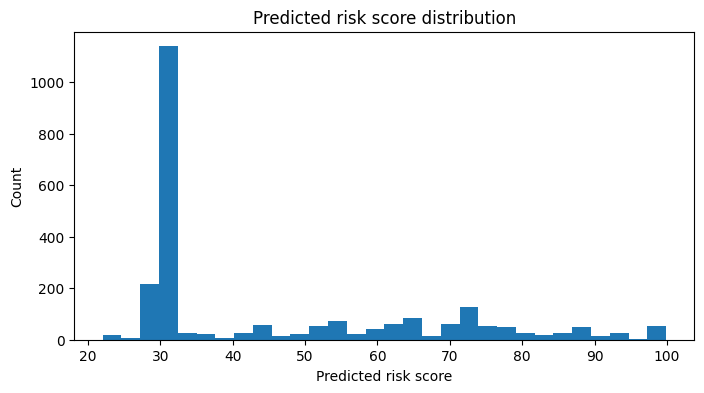

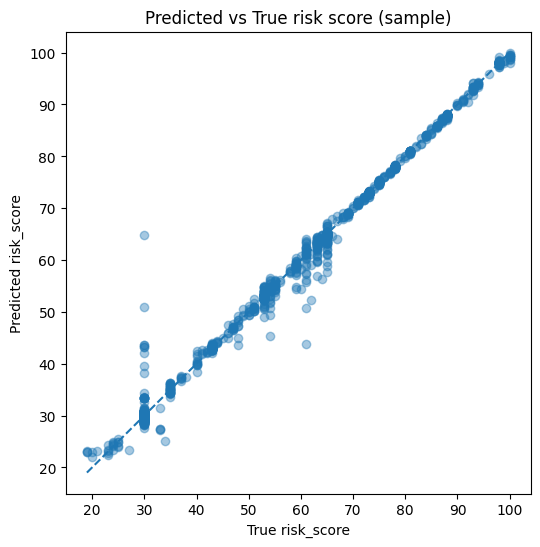

In [31]:
# Cell 6: simple visual checks
plt.figure(figsize=(8,4))
plt.title("Predicted risk score distribution")
plt.hist(df["predicted_risk_score"], bins=30)
plt.xlabel("Predicted risk score")
plt.ylabel("Count")
plt.show()

# If true exists, scatter predicted vs true
if "risk_score" in df.columns:
    plt.figure(figsize=(6,6))
    plt.title("Predicted vs True risk score (sample)")
    plt.scatter(df["risk_score"], df["predicted_risk_score"], alpha=0.4)
    mn = min(df["risk_score"].min(), df["predicted_risk_score"].min())
    mx = max(df["risk_score"].max(), df["predicted_risk_score"].max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("True risk_score")
    plt.ylabel("Predicted risk_score")
    plt.show()
else:
    print("True risk_score not present, skipping scatter plot.")